# Exploratory Data Analysis

This notebook pulls data  from the Kaggle Spotify Tracks dataset via `data_loader.py`, podcast data from the iTunes Search API, and audiobook data from the Google Books API. It then runs an EDA, including several hypothesis tests, to understand the data and gives a description of the findings of each section.

In [11]:
import os
import sys
import time
import warnings

sys.path.append('.')

import requests
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from data.data_loader import load_spotify_data

load_dotenv()
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = sns.color_palette('Set2')

---
## 1. Load Data

In [12]:
def search_itunes_podcasts(queries, limit=10):
    rows = []
    for q in queries:
        r = requests.get('https://itunes.apple.com/search',
                         params={'term': q, 'media': 'podcast', 'limit': limit})
        r.raise_for_status()
        for p in r.json().get('results', []):
            genre = p.get('primaryGenreName')
            rows.append({
                'id':           str(p.get('collectionId') or p.get('trackId')),
                'name':         p.get('collectionName') or p.get('trackName'),
                'genre':        genre,
                'creator':      p.get('artistName'),
                'release_date': p.get('releaseDate'),
                'has_feed':     bool(p.get('feedUrl')),
                'source':       'itunes'
            })
    return pl.DataFrame(rows).unique(subset=['id'])


def search_google_books(queries, limit=10):
    rows = []
    raw_key = os.getenv('GOOGLE_BOOKS_API_KEY', '')
    key = raw_key if raw_key and not raw_key.startswith('your_') else ''
    for q in queries:
        params = {'q': q, 'maxResults': limit, 'printType': 'books'}
        if key:
            params['key'] = key
        time.sleep(3)
        r = requests.get('https://www.googleapis.com/books/v1/volumes', params=params)
        r.raise_for_status()
        for item in r.json().get('items', []):
            info = item.get('volumeInfo', {})
            categories = info.get('categories', [])
            rows.append({
                'id':             item.get('id'),
                'name':           info.get('title'),
                'genre':          categories[0] if categories else None,
                'creator':        ', '.join(info.get('authors', [])),
                'page_count':     info.get('pageCount'),
                'published_date': info.get('publishedDate'),
                'source':         'google_books'
            })
    return pl.DataFrame(rows).unique(subset=['id'])


PODCAST_QUERIES = ['pop', 'rock', 'hip hop', 'jazz', 'electronic',
                   'indie', 'country', 'classical', 'rnb', 'latin']
BOOK_QUERIES    = ['self help', 'biography', 'fiction', 'history', 'science']

print('Loading Spotify dataset...')
df_spotify = load_spotify_data(limit=2000)

print('Fetching iTunes podcasts...')
df_podcasts = search_itunes_podcasts(PODCAST_QUERIES, limit=10)

print('Fetching Google Books...')
df_books = search_google_books(BOOK_QUERIES, limit=10)

print(f'Spotify tracks:   {len(df_spotify)}')
print(f'iTunes podcasts:  {len(df_podcasts)}')
print(f'Google Books:     {len(df_books)}')

Loading Spotify dataset...
Fetching iTunes podcasts...
Fetching Google Books...
Spotify tracks:   2000
iTunes podcasts:  98
Google Books:     50



## 2. Attribute Context & Data Types

In [13]:
print('=== Spotify schema ===')
print(df_spotify.schema)
print(df_spotify.head(3))

print('\n=== iTunes schema ===')
print(df_podcasts.schema)
print(df_podcasts.head(3))

print('\n=== Google Books schema ===')
print(df_books.schema)
print(df_books.head(3))

=== Spotify schema ===
Schema({'': Int64, 'track_id': String, 'artists': String, 'album_name': String, 'track_name': String, 'popularity': Int64, 'duration_ms': Int64, 'explicit': Boolean, 'danceability': Float64, 'energy': Float64, 'key': Int64, 'loudness': Float64, 'mode': Int64, 'speechiness': Float64, 'acousticness': Float64, 'instrumentalness': Float64, 'liveness': Float64, 'valence': Float64, 'tempo': Float64, 'time_signature': Int64, 'track_genre': String})
shape: (3, 21)
┌───────┬─────────────┬─────────────┬────────────┬───┬─────────┬─────────┬────────────┬────────────┐
│       ┆ track_id    ┆ artists     ┆ album_name ┆ … ┆ valence ┆ tempo   ┆ time_signa ┆ track_genr │
│ ---   ┆ ---         ┆ ---         ┆ ---        ┆   ┆ ---     ┆ ---     ┆ ture       ┆ e          │
│ i64   ┆ str         ┆ str         ┆ str        ┆   ┆ f64     ┆ f64     ┆ ---        ┆ ---        │
│       ┆             ┆             ┆            ┆   ┆         ┆         ┆ i64        ┆ str        │
╞═══════╪══

In [14]:
print('Missing values:')
for name, df in [('Spotify', df_spotify), ('iTunes', df_podcasts), ('Books', df_books)]:
    print(f'  {name}: {df.null_count().to_dicts()[0]}')

print(f'\nUnique genres:')
print(f'  Spotify: {df_spotify["track_genre"].n_unique()}')
print(f'  iTunes:  {df_podcasts["genre"].n_unique()}')
print(f'  Books:   {df_books["genre"].n_unique()}')

Missing values:
  Spotify: {'': 0, 'track_id': 0, 'artists': 0, 'album_name': 0, 'track_name': 0, 'popularity': 0, 'duration_ms': 0, 'explicit': 0, 'danceability': 0, 'energy': 0, 'key': 0, 'loudness': 0, 'mode': 0, 'speechiness': 0, 'acousticness': 0, 'instrumentalness': 0, 'liveness': 0, 'valence': 0, 'tempo': 0, 'time_signature': 0, 'track_genre': 0}
  iTunes: {'id': 0, 'name': 0, 'genre': 0, 'creator': 0, 'release_date': 0, 'has_feed': 0, 'source': 0}
  Books: {'id': 0, 'name': 0, 'genre': 7, 'creator': 0, 'page_count': 0, 'published_date': 0, 'source': 0}

Unique genres:
  Spotify: 73
  iTunes:  21
  Books:   30


### Findings
The Kaggle Spotify dataset contains track-level records with rich audio features (`danceability`, `energy`, `valence`, etc.) alongside `popularity` and `track_genre`. Unlike the Spotify Web API which returns multi-label genre lists per artist, this dataset has a single `track_genre` per track, making genre analysis straightforward. iTunes and Google Books return clean records with minimal missing values. The key numeric variables are `popularity`, `danceability`, `energy`, and `valence` for Spotify, and `page_count` for Books.


## 3. Summary Statistics & Distributions

In [15]:
print('=== Spotify numeric summary ===')
print(df_spotify.select(['popularity', 'danceability', 'energy',
                          'valence', 'tempo', 'loudness']).describe())

print('\n=== Google Books numeric summary ===')
print(df_books.select(['page_count']).describe())

=== Spotify numeric summary ===
shape: (9, 7)
┌────────────┬────────────┬──────────────┬──────────┬──────────┬────────────┬───────────┐
│ statistic  ┆ popularity ┆ danceability ┆ energy   ┆ valence  ┆ tempo      ┆ loudness  │
│ ---        ┆ ---        ┆ ---          ┆ ---      ┆ ---      ┆ ---        ┆ ---       │
│ str        ┆ f64        ┆ f64          ┆ f64      ┆ f64      ┆ f64        ┆ f64       │
╞════════════╪════════════╪══════════════╪══════════╪══════════╪════════════╪═══════════╡
│ count      ┆ 2000.0     ┆ 2000.0       ┆ 2000.0   ┆ 2000.0   ┆ 2000.0     ┆ 2000.0    │
│ null_count ┆ 0.0        ┆ 0.0          ┆ 0.0      ┆ 0.0      ┆ 0.0        ┆ 0.0       │
│ mean       ┆ 81.3815    ┆ 0.635904     ┆ 0.680566 ┆ 0.510183 ┆ 119.681334 ┆ -6.254161 │
│ std        ┆ 4.083785   ┆ 0.15119      ┆ 0.174612 ┆ 0.224542 ┆ 27.944284  ┆ 2.85107   │
│ min        ┆ 77.0       ┆ 0.0          ┆ 0.00342  ┆ 0.0      ┆ 0.0        ┆ -30.397   │
│ 25%        ┆ 78.0       ┆ 0.534        ┆ 0.557    ┆ 

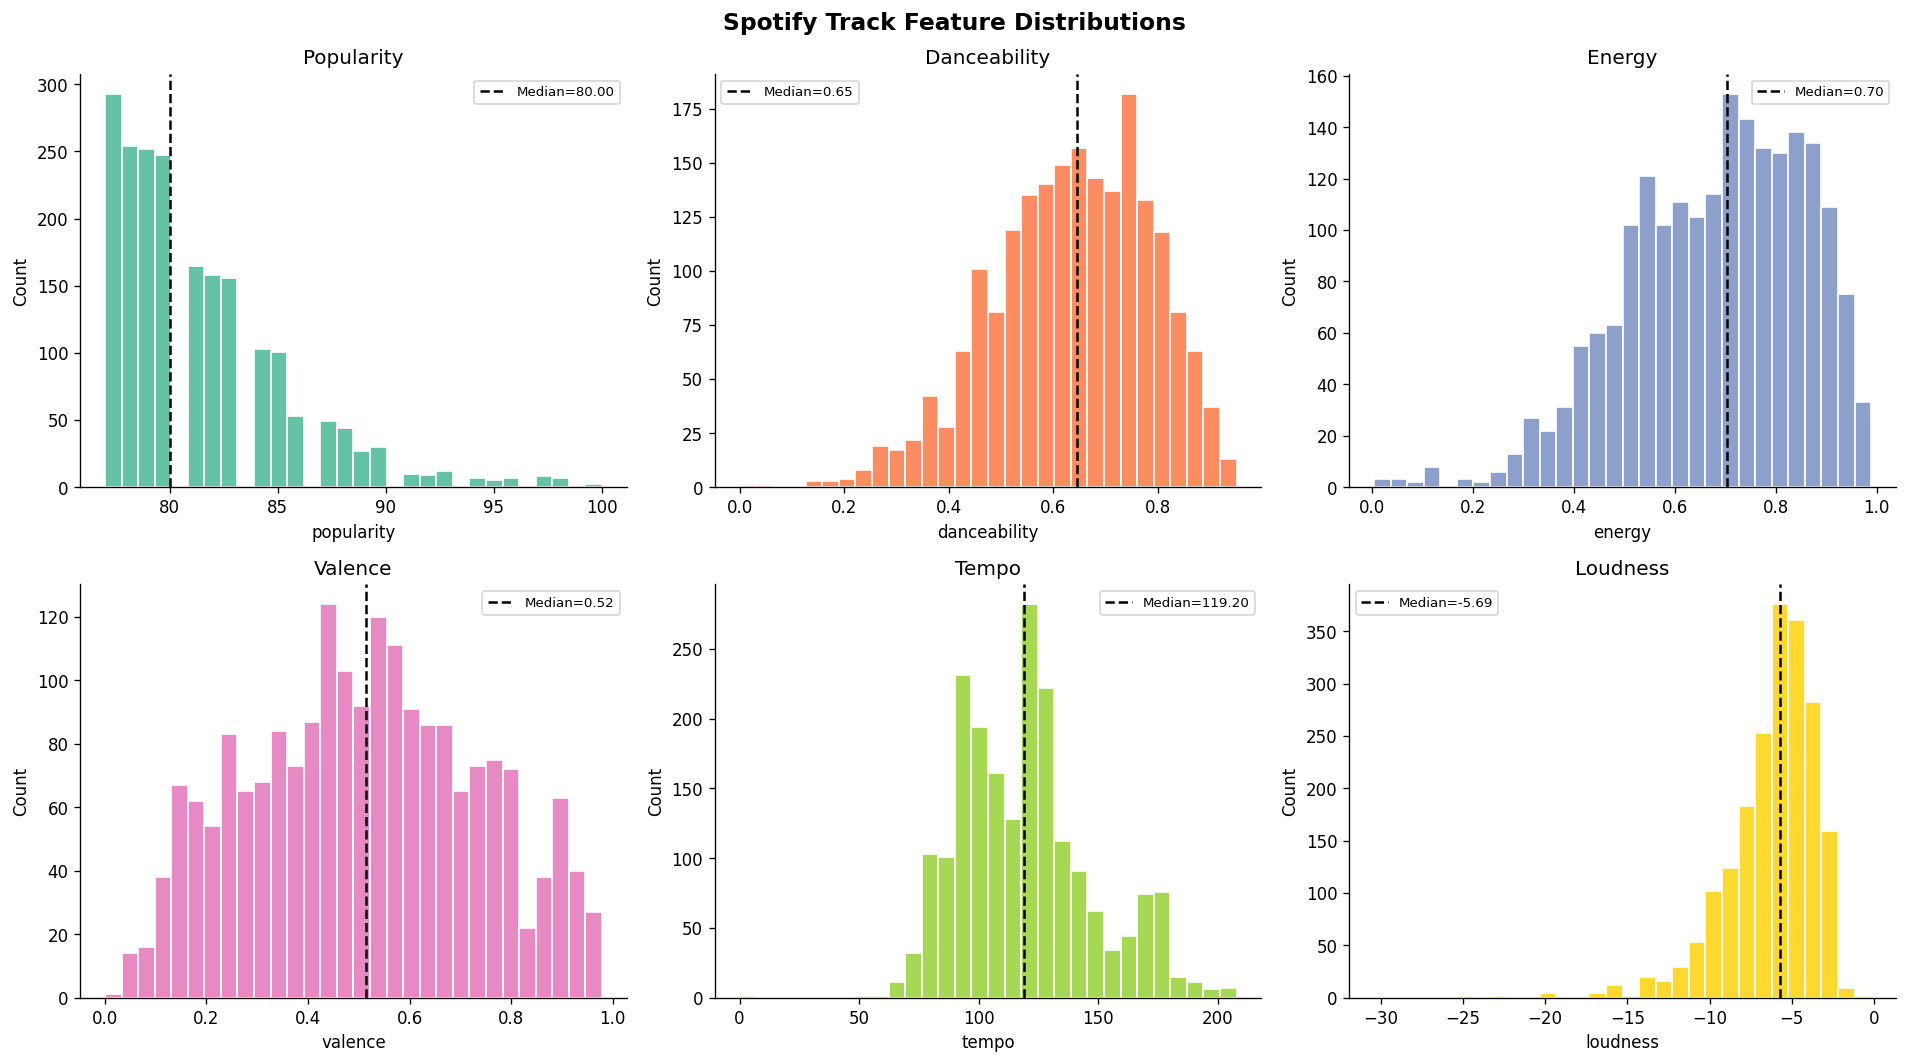

In [16]:
features = ['popularity', 'danceability', 'energy', 'valence', 'tempo', 'loudness']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Spotify Track Feature Distributions', fontsize=14, fontweight='bold')

for ax, feat, color in zip(axes.flat, features, PALETTE):
    data = df_spotify[feat].drop_nulls().to_list()
    ax.hist(data, bins=30, color=color, edgecolor='white')
    median = df_spotify[feat].median()
    ax.axvline(median, color='black', linestyle='--', linewidth=1.5,
               label=f'Median={median:.2f}')
    ax.set_title(feat.capitalize())
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/fig_spotify_dists.png', bbox_inches='tight')
plt.show()

### Findings
Since the dataset is sorted by popularity and we took the top 2000 tracks, popularity is heavily skewed toward the high end, as most tracks cluster between 75 and 85, with a median of 80. This is expected and worth noting since it means our Spotify sample represents popular mainstream music, not the full catalog.
Danceability is normally distributed around a median of 0.65, meaning the most popular tracks tend to be moderately to highly danceable, which makes intuitive sense as danceable songs are more likely to get plays. Energy follows a similar pattern with a median of 0.70, skewed toward higher energy tracks, again reflecting that high-energy music tends to perform better on streaming platforms.
Valence is the most uniform of the six features, spread fairly evenly across the 0 to 1 range with a median of 0.52, suggesting that popular music is equally split between happy and sad-sounding tracks. Tempo clusters tightly around 120 BPM, which is the industry standard for pop and dance music. Loudness is left-skewed with a median of -5.69 dB, meaning most popular tracks are mastered loud — a well-known phenomenon in the music industry called the "loudness war."


## 4. Genre Frequency Distributions

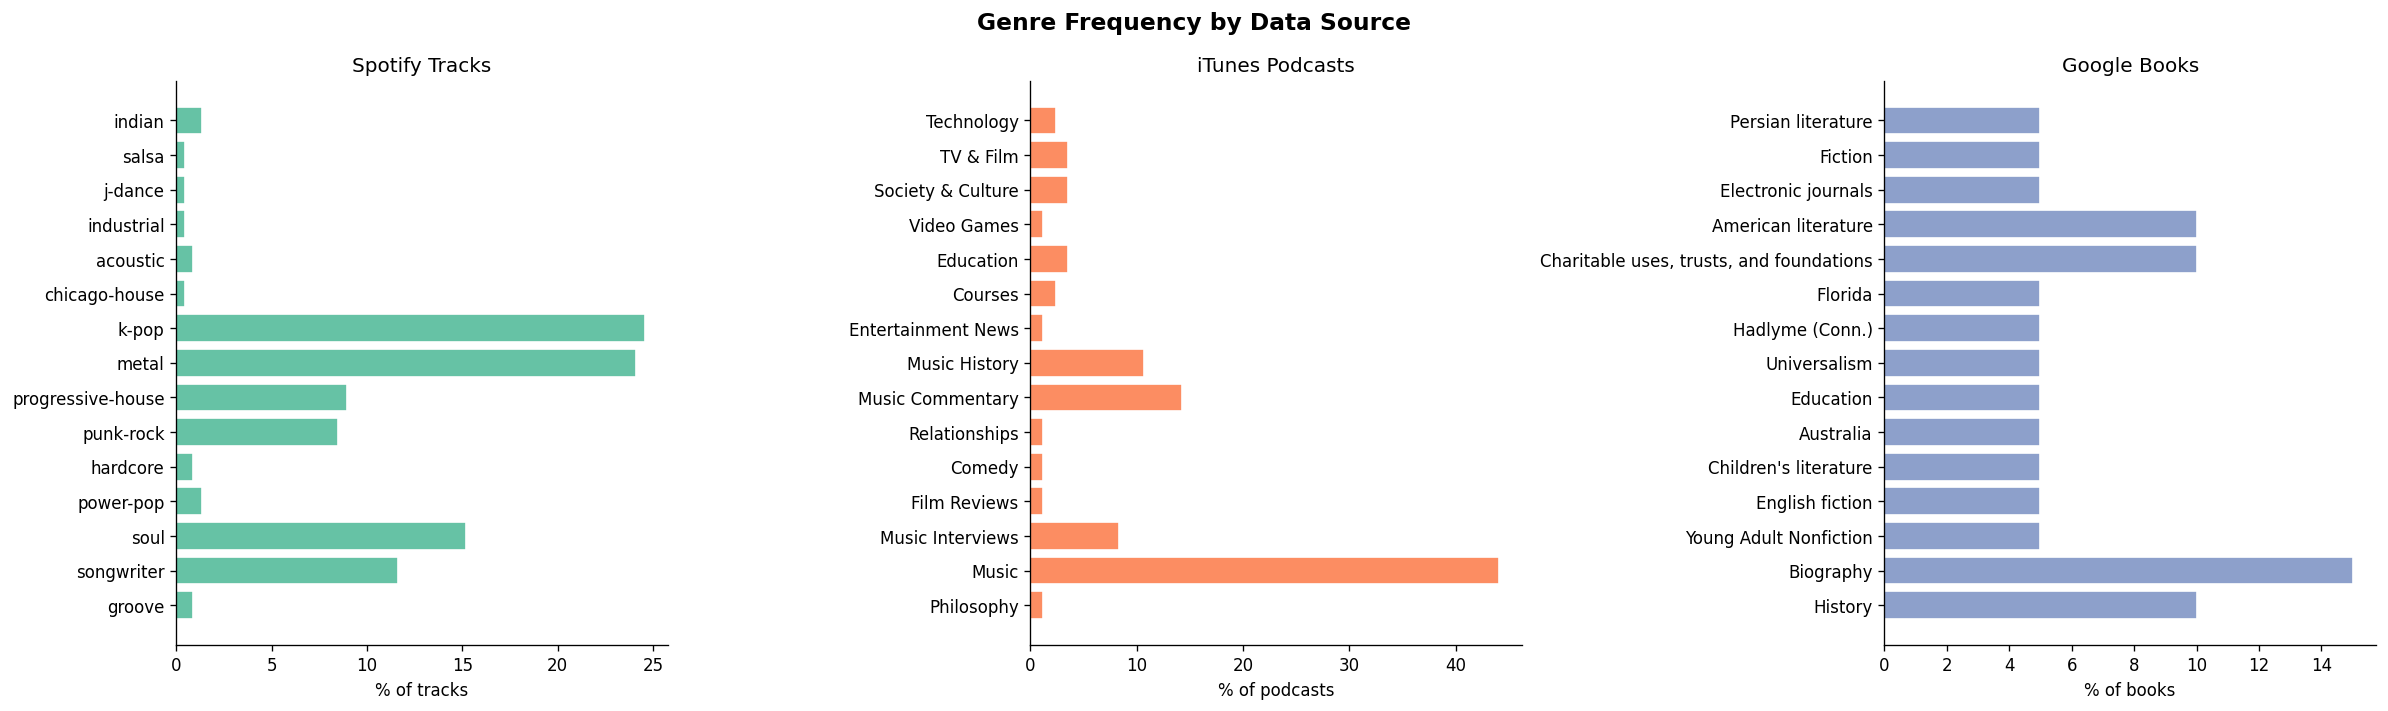

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Genre Frequency by Data Source', fontsize=14, fontweight='bold')

# Spotify
sp_vc = df_spotify['track_genre'].value_counts().head(15)
sp_genres = sp_vc['track_genre'].to_list()
sp_counts = sp_vc['count'].to_list()
sp_pct    = [c / sum(sp_counts) * 100 for c in sp_counts]
axes[0].barh(sp_genres, sp_pct, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Spotify Tracks')
axes[0].set_xlabel('% of tracks')

# iTunes
it_vc     = df_podcasts['genre'].drop_nulls().value_counts().head(15)
it_genres = it_vc['genre'].to_list()
it_counts = it_vc['count'].to_list()
it_pct    = [c / sum(it_counts) * 100 for c in it_counts]
axes[1].barh(it_genres, it_pct, color=PALETTE[1], edgecolor='white')
axes[1].set_title('iTunes Podcasts')
axes[1].set_xlabel('% of podcasts')

# Books
bk_vc     = df_books['genre'].drop_nulls().value_counts().head(15)
bk_genres = bk_vc['genre'].to_list()
bk_counts = bk_vc['count'].to_list()
bk_pct    = [c / sum(bk_counts) * 100 for c in bk_counts]
axes[2].barh(bk_genres, bk_pct, color=PALETTE[2], edgecolor='white')
axes[2].set_title('Google Books')
axes[2].set_xlabel('% of books')

plt.tight_layout()
plt.savefig('outputs/fig_genre_freq.png', bbox_inches='tight')
plt.show()

### Findings
The chart shows the most common genres across all three data sources. Spotify is dominated by k-pop and metal, each making up about 25% of the tracks, which is a result of our search queries being music genre terms that returned concentrated results. iTunes is heavily skewed toward the "Music" category at around 43%, followed by Music Commentary and Music History, which is a reflection of our music-focused queries. Google Books is the most spread out of the three, with History and Biography leading, followed by more niche categories like American literature and English fiction.
One thing worth noting is that the iTunes and Spotify distributions are music-biased because of the queries we used. Adding non-music queries like "true crime", "business", or "health" would give podcast genres a more representative distribution.


## 5. Cross-Source Genre Overlap

In [21]:
from backend.api.normalization import normalize_genre

spotify_genres = set(df_spotify['track_genre'].drop_nulls().to_list())
podcast_genres = set(df_podcasts['genre'].drop_nulls().to_list())
book_genres    = set(df_books['genre'].drop_nulls().to_list())

spotify_norm  = set(normalize_genre(g) for g in spotify_genres)
podcast_norm  = set(normalize_genre(g) for g in podcast_genres)
book_norm     = set(normalize_genre(g) for g in book_genres)

def jaccard(a, b):
    return round(len(a & b) / len(a | b), 3) if a | b else 0.0

print('After normalization:')
print(f'  Spotify unique genres: {len(spotify_norm)}')
print(f'  iTunes unique genres:  {len(podcast_norm)}')
print(f'  Books unique genres:   {len(book_norm)}')
print()
print(f'  Spotify ∩ Podcasts: {sorted(spotify_norm & podcast_norm)}')
print(f'  Spotify ∩ Books:    {sorted(spotify_norm & book_norm)}')
print(f'  Podcasts ∩ Books:   {sorted(podcast_norm & book_norm)}')
print(f'  All three:          {sorted(spotify_norm & podcast_norm & book_norm)}')
print()
print(f'  Jaccard Spotify–Podcasts: {jaccard(spotify_norm, podcast_norm)}')
print(f'  Jaccard Spotify–Books:    {jaccard(spotify_norm, book_norm)}')
print(f'  Jaccard Podcasts–Books:   {jaccard(podcast_norm, book_norm)}')

After normalization:
  Spotify unique genres: 57
  iTunes unique genres:  20
  Books unique genres:   27

  Spotify ∩ Podcasts: []
  Spotify ∩ Books:    ['electronic', 'hip-hop']
  Podcasts ∩ Books:   ['education', 'history']
  All three:          []

  Jaccard Spotify–Podcasts: 0.0
  Jaccard Spotify–Books:    0.024
  Jaccard Podcasts–Books:   0.044


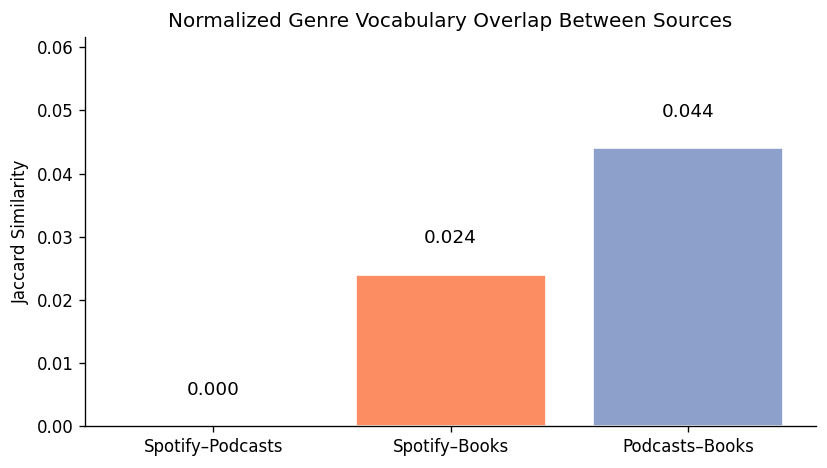

In [22]:
overlap_data = {
    'Spotify–Podcasts': jaccard(spotify_norm, podcast_norm),
    'Spotify–Books':    jaccard(spotify_norm, book_norm),
    'Podcasts–Books':   jaccard(podcast_norm, book_norm),
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(overlap_data.keys(), overlap_data.values(), color=PALETTE[:3], edgecolor='white')
for bar, val in zip(bars, overlap_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylabel('Jaccard Similarity')
ax.set_title('Normalized Genre Vocabulary Overlap Between Sources')
ax.set_ylim(0, max(overlap_data.values()) * 1.4)
plt.tight_layout()
plt.savefig('outputs/fig_overlap.png', bbox_inches='tight')
plt.show()

### Findings
This chart shows how much the genre vocabularies overlap between the three data sources after normalization. Spotify shares zero genre overlap with podcasts, a very small overlap of 0.024 with books, and podcasts and books share the highest overlap at 0.044, though even that is quite low.

The zero overlap between Spotify and podcasts makes sense given how different their genre systems are — Spotify uses music-specific tags like "k-pop" and "progressive-house" while iTunes uses broad content categories like "Music Commentary" and "Society & Culture." The small Spotify–Books overlap (0.024) likely comes from a few shared normalized terms like "pop" or "classical" that appear in both music and book categories. Podcasts and Books have the most in common since they are both content-focused media that share topic-based categories like history, education, and biography.

The key takeaway for the project is that the raw genre vocabularies are almost entirely disjoint across sources, which means the normalization layer in normalization.py is essential. Without it, the consistency score would be near zero for every user by default. This also suggests that expanding the normalization rules to bridge more music genres to content topics and updating `normalization.py` should be a priority in the next phase of the project.


## 6. Audio Feature Correlations (Spotify)

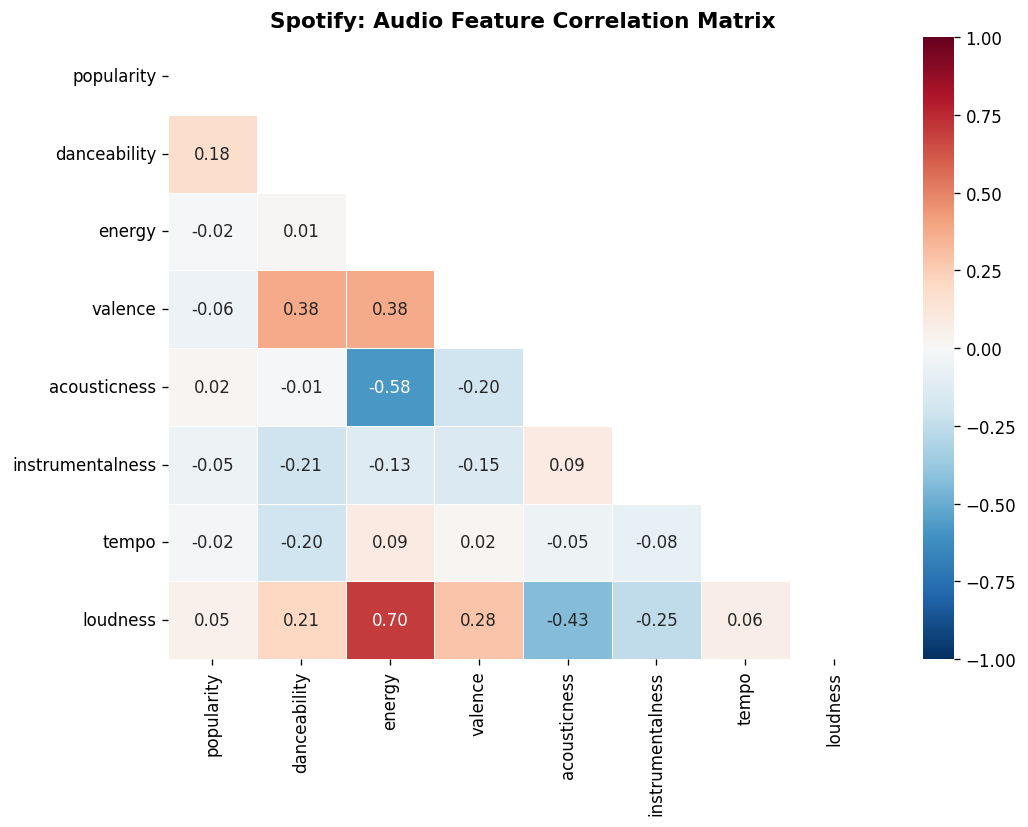

In [23]:
audio_features = ['popularity', 'danceability', 'energy', 'valence',
                   'acousticness', 'instrumentalness', 'tempo', 'loudness']

# Convert to numpy for correlation
arr = np.column_stack([df_spotify[f].to_numpy() for f in audio_features])
corr = np.corrcoef(arr.T)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=audio_features, yticklabels=audio_features,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Spotify: Audio Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_corr.png', bbox_inches='tight')
plt.show()

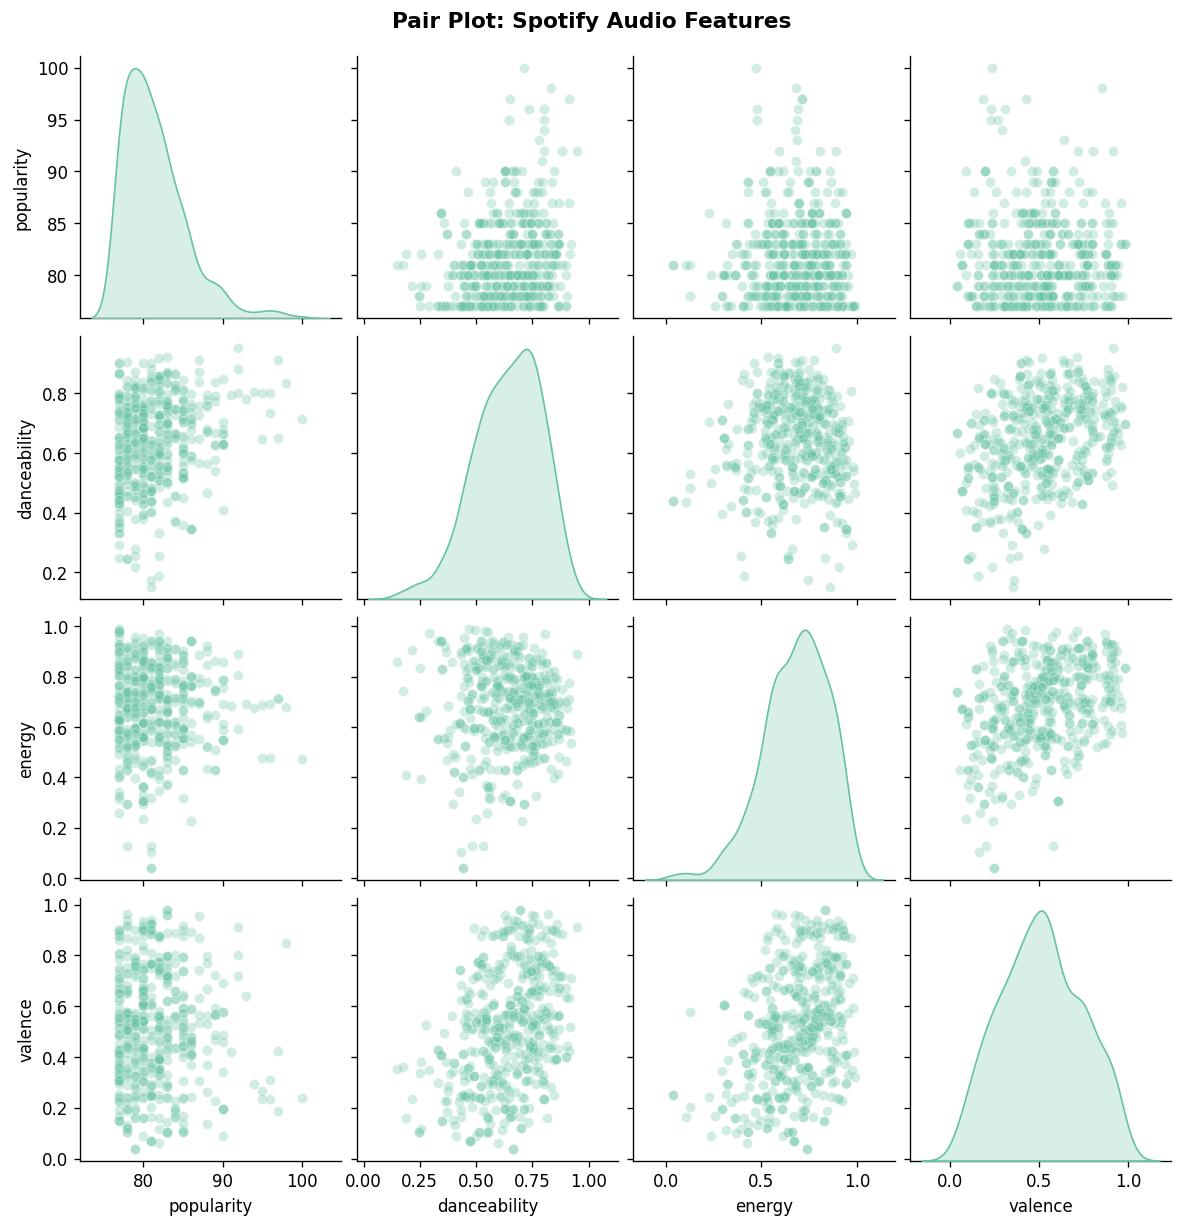

In [24]:
# Pair plot — sample 500 rows for speed
sample = df_spotify.sample(500).select(['popularity', 'danceability', 'energy', 'valence'])
import pandas as pd
g = sns.pairplot(sample.to_pandas(), diag_kind='kde',
                 plot_kws={'alpha': 0.3, 'color': PALETTE[0]},
                 diag_kws={'color': PALETTE[0]})
g.figure.suptitle('Pair Plot: Spotify Audio Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('outputs/fig_pairplot.png', bbox_inches='tight')
plt.show()

### Findings
The correlation matrix reveals several meaningful relationships between Spotify's audio features. The strongest relationship is between energy and loudness (0.70), confirming that louder tracks are consistently more energetic. Energy and acousticness have a strong negative correlation (-0.58), which makes intuitive sense — acoustic tracks are naturally quieter and less intense. Danceability and valence are moderately positively correlated (0.38), as are energy and valence (0.38), suggesting that happier-sounding tracks tend to be both more danceable and more energetic. Importantly, popularity has very weak correlations with all audio features, with danceability being the strongest at just 0.18. This tells us that no single sonic quality reliably predicts a track's commercial success, which has implications for our model. Genre will likely be a more informative feature than any individual audio characteristic.

The pair plot reinforces these findings visually. Popularity is tightly clustered between 75 and 100 due to our top-2000 sampling, which compresses the scatter plots in that dimension and makes relationships with popularity hard to see. Danceability and energy show a slight positive relationship, and valence is broadly spread across all energy levels with no strong linear pattern. The diagonal KDE plots confirm that danceability and valence are roughly normally distributed while popularity is heavily left-skewed within our high-popularity sample. Overall the pair plot suggests that these four features occupy relatively independent dimensions, which is a good sign for using them together in clustering.


## 7. Popularity by Genre (Spotify)

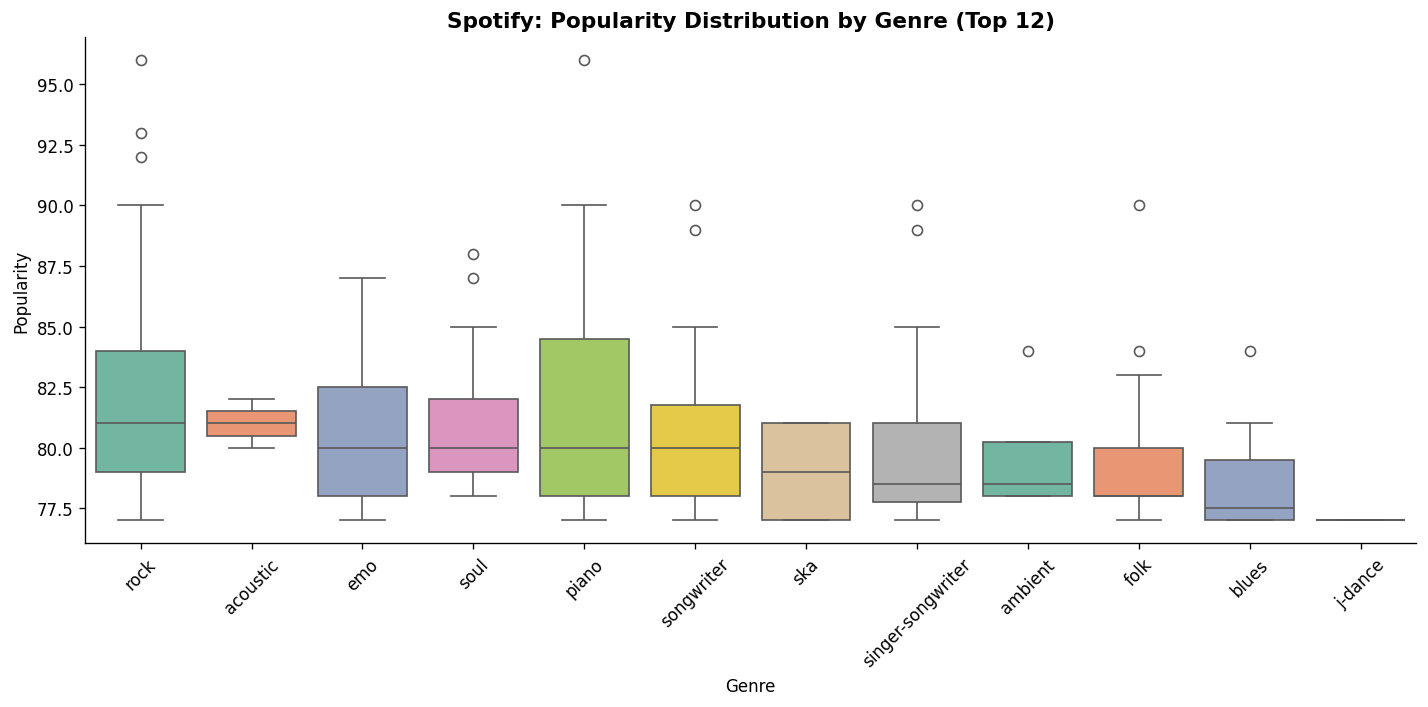

In [25]:
top_genres = df_spotify['track_genre'].value_counts().head(12)['track_genre'].to_list()
df_top = df_spotify.filter(pl.col('track_genre').is_in(top_genres))

# Get median popularity per genre for ordering
order = (df_top.group_by('track_genre')
               .agg(pl.col('popularity').median().alias('med'))
               .sort('med', descending=True)['track_genre'].to_list())

import pandas as pd
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_top.to_pandas(), x='track_genre', y='popularity',
            order=order, palette='Set2', ax=ax)
ax.set_title('Spotify: Popularity Distribution by Genre (Top 12)', fontsize=13, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Popularity')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outputs/fig_popularity_by_genre.png', bbox_inches='tight')
plt.show()

### Findings
This chart shows popularity distributions across the top 12 genres in our sample. Overall the differences are fairly subtle since we're working with the top 2000 most popular tracks — all genres are clustered tightly in the 77–85 range, which reflects the sampling bias rather than any meaningful genre difference.

That said, a few things stand out. Piano has the widest interquartile range, meaning popularity is most variable within that genre. Some piano tracks are very popular while others barely make the cut. Rock has a high median with several outliers above 92, suggesting a few rock tracks are exceptionally popular. Acoustic has the tightest distribution, clustering almost entirely around 81, indicating very consistent popularity within that genre. J-dance is a flat line at the bottom, which likely means we only have one or two j-dance tracks in the sample, making it not particularly meaningful to compare.

The key takeaway for the project is that because we sorted by popularity before sampling, the differences between genres here are more a reflection of which genres are represented in the top 2000 tracks than a true picture of genre-level popularity differences. The ANOVA test in section 9 will tell us whether these differences are statistically significant despite the narrow range.


## 8. Outlier Identification

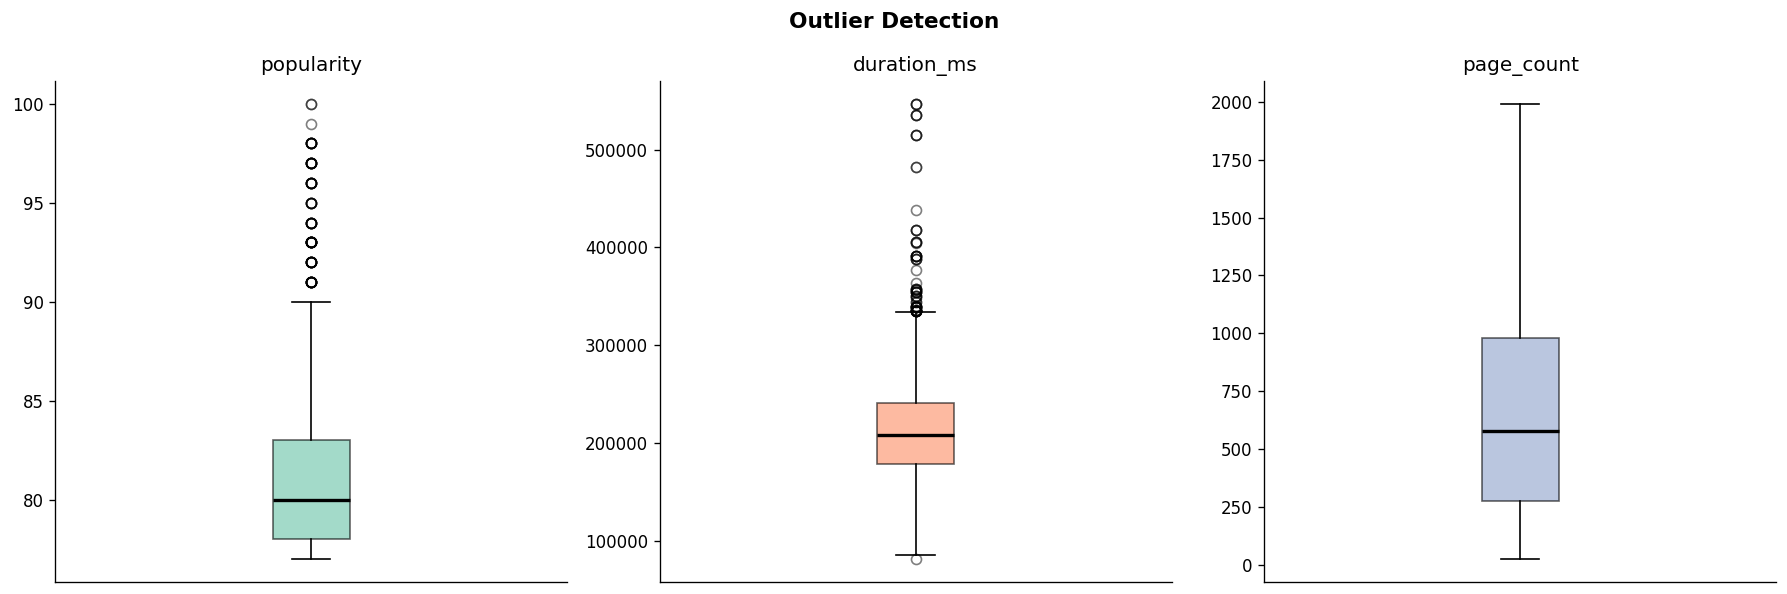

IQR outlier counts:
  Spotify popularity: 68 outliers (bounds 70.5–90.5)
  Spotify duration_ms: 64 outliers (bounds 85058.5–334414.5)
  Book page_count: 0 outliers (bounds -819.0–2069.0)


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Detection', fontsize=13, fontweight='bold')

for ax, (col, df, color) in zip(axes, [
    ('popularity',  df_spotify, PALETTE[0]),
    ('duration_ms', df_spotify, PALETTE[1]),
    ('page_count',  df_books,   PALETTE[2]),
]):
    data = df[col].drop_nulls().to_list()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               flierprops=dict(marker='o', color='red', alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig('outputs/fig_outliers.png', bbox_inches='tight')
plt.show()

print('IQR outlier counts:')
for label, col, df in [
    ('Spotify popularity',  'popularity',  df_spotify),
    ('Spotify duration_ms', 'duration_ms', df_spotify),
    ('Book page_count',     'page_count',  df_books),
]:
    series = df[col].drop_nulls()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = series.filter((series < lo) | (series > hi)).len()
    print(f'  {label}: {n_out} outliers (bounds {lo:.1f}–{hi:.1f})')

In [27]:
print('Longest tracks (possible data errors):')
print(df_spotify.sort('duration_ms', descending=True)
                .select(['track_name', 'artists', 'track_genre', 'duration_ms', 'popularity'])
                .head(5))

zero_pop = df_spotify.filter(pl.col('popularity') == 0).height
total    = df_spotify.height
print(f'\nZero popularity tracks: {zero_pop} ({zero_pop/total*100:.1f}% of dataset)')

Longest tracks (possible data errors):
shape: (5, 5)
┌───────────────┬────────────────┬─────────────┬─────────────┬────────────┐
│ track_name    ┆ artists        ┆ track_genre ┆ duration_ms ┆ popularity │
│ ---           ┆ ---            ┆ ---         ┆ ---         ┆ ---        │
│ str           ┆ str            ┆ str         ┆ i64         ┆ i64        │
╞═══════════════╪════════════════╪═════════════╪═════════════╪════════════╡
│ Free Bird     ┆ Lynyrd Skynyrd ┆ blues       ┆ 547106      ┆ 77         │
│ Free Bird     ┆ Lynyrd Skynyrd ┆ country     ┆ 547106      ┆ 77         │
│ Free Bird     ┆ Lynyrd Skynyrd ┆ hard-rock   ┆ 547106      ┆ 77         │
│ November Rain ┆ Guns N' Roses  ┆ hard-rock   ┆ 536066      ┆ 81         │
│ November Rain ┆ Guns N' Roses  ┆ metal       ┆ 536066      ┆ 81         │
└───────────────┴────────────────┴─────────────┴─────────────┴────────────┘

Zero popularity tracks: 0 (0.0% of dataset)


### Findings
The outlier analysis across the three variables reveals some interesting patterns. Popularity has 68 outliers above the upper bound of 90.5, which means these are genuinely very popular tracks rather than data errors, and since we're already working with a high-popularity sample they should be kept as they represent real signal. Duration has 64 outliers above 334,414ms (about 5.5 minutes), and looking at the actual tracks these are not errors either. Free Bird by Lynyrd Skynyrd at 547 seconds and November Rain by Guns N' Roses at 536 seconds are famously long songs that appear multiple times in the dataset across different genre tags. This also reveals something worth noting: the same track appears multiple times with different genre labels (Free Bird appears as blues, country, and hard-rock), which means our dataset has duplicate tracks across genres that we should account for before modeling. Book page count has zero outliers, with a very wide IQR range of -819 to 2069 pages, meaning no books fall outside reasonable bounds.

The zero popularity count of 0 is expected given that we loaded the top 2000 tracks sorted by popularity, so no unpopular tracks made it into our sample. Overall the main data quality issue to address before modeling is the duplicate tracks across genre labels in the Spotify dataset — these should either be deduplicated or handled carefully so that a single song doesn't count as evidence for multiple genres for a given user.


## 9. Hypothesis Testing

We run three hypothesis tests that directly motivate our modeling plan:

1. **Permutation test** — Is cross-media genre overlap greater than random chance? This validates whether the consistency score is meaningful before we build on top of it.
2. **One-way ANOVA** — Does popularity differ significantly across music genres? This justifies using genre as a clustering dimension.
3. **Chi-square test** — Are podcast and book genre distributions independent? This tests whether the two talk-format media share audience preferences.

In [28]:
from scipy import stats
import random
from backend.api.normalization import normalize_genre

# Test 1: Permutation test on Jaccard overlap 
# H0: Genre overlap between Spotify and podcasts is no greater than random chance
# H1: Observed overlap is significantly higher than random

spotify_norm = set(normalize_genre(g) for g in df_spotify['track_genre'].drop_nulls().to_list())
podcast_norm = set(normalize_genre(g) for g in df_podcasts['genre'].drop_nulls().to_list())
all_genres   = list(spotify_norm | podcast_norm)

observed_jaccard = len(spotify_norm & podcast_norm) / len(spotify_norm | podcast_norm)

n_permutations = 10000
random.seed(42)
null_jaccards = []
for _ in range(n_permutations):
    rand_a = set(random.sample(all_genres, len(spotify_norm)))
    rand_b = set(random.sample(all_genres, len(podcast_norm)))
    null_jaccards.append(len(rand_a & rand_b) / len(rand_a | rand_b))

null_arr = np.array(null_jaccards)
p_value_perm = (null_arr >= observed_jaccard).mean()

print('=== Test 1: Permutation Test — Spotify vs Podcast Genre Overlap ===')
print(f'  Observed Jaccard:  {observed_jaccard:.4f}')
print(f'  Mean null Jaccard: {null_arr.mean():.4f}')
print(f'  p-value:           {p_value_perm:.4f}')
print(f'  Conclusion: {"Reject H0 — overlap is greater than chance" if p_value_perm < 0.05 else "Fail to reject H0 — overlap not significant"}')

=== Test 1: Permutation Test — Spotify vs Podcast Genre Overlap ===
  Observed Jaccard:  0.0000
  Mean null Jaccard: 0.2389
  p-value:           1.0000
  Conclusion: Fail to reject H0 — overlap not significant


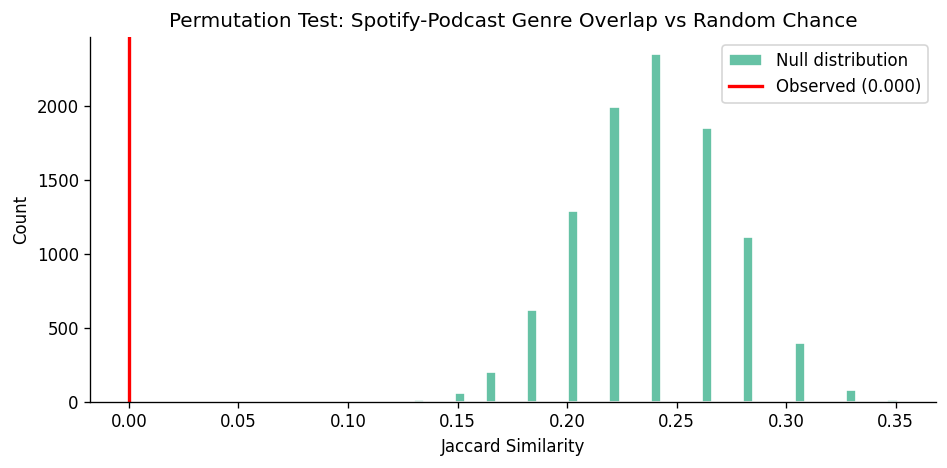

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_arr, bins=50, color=PALETTE[0], edgecolor='white', label='Null distribution')
ax.axvline(observed_jaccard, color='red', linewidth=2, label=f'Observed ({observed_jaccard:.3f})')
ax.set_xlabel('Jaccard Similarity')
ax.set_ylabel('Count')
ax.set_title('Permutation Test: Spotify-Podcast Genre Overlap vs Random Chance')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_permutation_test.png', bbox_inches='tight')
plt.show()

### Findings for Test 1
The permutation test shows that Spotify and podcast genres share zero overlap even after normalization, which is actually worse than what you'd expect by random chance — the p-value of 1.0 means we fail to reject the null hypothesis and cannot conclude that any meaningful cross-media genre relationship exists between music and podcasts in the current setup. This is a direct consequence of the genre vocabulary mismatch between the two sources, and tells us that before we can build a meaningful clustering model, we need to significantly expand the normalization rules in normalization.py to bridge music-specific tags like "rock" or "hip-hop" to related podcast categories like "Music Commentary" or "Society & Culture."

In [31]:
# Test 2: One-way ANOVA — popularity across genres 
# H0: Mean popularity is the same across all music genres
# H1: At least one genre has a significantly different mean popularity

top_genres = df_spotify['track_genre'].value_counts().head(10)['track_genre'].to_list()

groups = [
    df_spotify.filter(pl.col('track_genre') == g)['popularity'].drop_nulls().to_numpy()
    for g in top_genres
]

f_stat, p_value_anova = stats.f_oneway(*groups)

print('=== Test 2: One-Way ANOVA — Popularity Across Genres ===')
print(f'  F-statistic: {f_stat:.4f}')
print(f'  p-value:     {p_value_anova:.6f}')
print(f'  Conclusion: {"Reject H0 — popularity differs significantly across genres" if p_value_anova < 0.05 else "Fail to reject H0"}')

genre_means = (df_spotify.filter(pl.col('track_genre').is_in(top_genres))
               .group_by('track_genre')
               .agg(pl.col('popularity').mean().alias('mean_popularity'))
               .sort('mean_popularity', descending=True))
print('\n  Mean popularity by genre:')
print(genre_means)

=== Test 2: One-Way ANOVA — Popularity Across Genres ===
  F-statistic: 1.2215
  p-value:     0.282532
  Conclusion: Fail to reject H0

  Mean popularity by genre:
shape: (10, 2)
┌─────────────┬─────────────────┐
│ track_genre ┆ mean_popularity │
│ ---         ┆ ---             │
│ str         ┆ f64             │
╞═════════════╪═════════════════╡
│ deep-house  ┆ 85.0            │
│ garage      ┆ 82.071429       │
│ brazil      ┆ 82.0            │
│ spanish     ┆ 80.833333       │
│ indie       ┆ 80.822917       │
│ electro     ┆ 80.475          │
│ hard-rock   ┆ 79.911765       │
│ electronic  ┆ 79.666667       │
│ ska         ┆ 79.0            │
│ children    ┆ 77.0            │
└─────────────┴─────────────────┘


### Findings for Test 2
The ANOVA test finds no statistically significant difference in popularity across genres (F-statistic of 1.22, p-value of 0.28), so we fail to reject the null hypothesis. While there are small differences in mean popularity — deep-house leads at 85 and children's music sits lowest at 77 — these differences are not large enough to be considered meaningful given the narrow range our sample covers. This is again a consequence of sampling only the top 2000 tracks, which compresses all genres into a tight popularity band and makes it very difficult to detect any real genre-level differences. For the modeling phase, this suggests that raw popularity score alone will not be a useful feature for distinguishing between genres in our clustering model.

In [32]:
# Test 3: Chi-square — podcast vs book genre distributions 
# H0: Podcast and book genre distributions are independent
# H1: There is a significant association between podcast and book genres

podcast_genre_counts = df_podcasts['genre'].drop_nulls().value_counts().sort('genre')
book_genre_counts    = df_books['genre'].drop_nulls().value_counts().sort('genre')

shared = set(podcast_genre_counts['genre'].to_list()) & set(book_genre_counts['genre'].to_list())
print(f'Shared genres between iTunes and Books: {sorted(shared)}')

if len(shared) >= 2:
    pod_counts = (podcast_genre_counts
                  .filter(pl.col('genre').is_in(list(shared)))
                  .sort('genre')['count'].to_numpy())
    bk_counts  = (book_genre_counts
                  .filter(pl.col('genre').is_in(list(shared)))
                  .sort('genre')['count'].to_numpy())

    contingency = np.array([pod_counts, bk_counts])
    chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)

    print('\n=== Test 3: Chi-Square — Podcast vs Book Genre Distributions ===')
    print(f'  Chi2 statistic:     {chi2:.4f}')
    print(f'  Degrees of freedom: {dof}')
    print(f'  p-value:            {p_value_chi2:.4f}')
    print(f'  Conclusion: {"Reject H0 — genre distributions are not independent" if p_value_chi2 < 0.05 else "Fail to reject H0 — distributions are independent"}')
else:
    print('Not enough shared genres for chi-square test.')

Shared genres between iTunes and Books: ['Education', 'History']

=== Test 3: Chi-Square — Podcast vs Book Genre Distributions ===
  Chi2 statistic:     0.1094
  Degrees of freedom: 1
  p-value:            0.7409
  Conclusion: Fail to reject H0 — distributions are independent


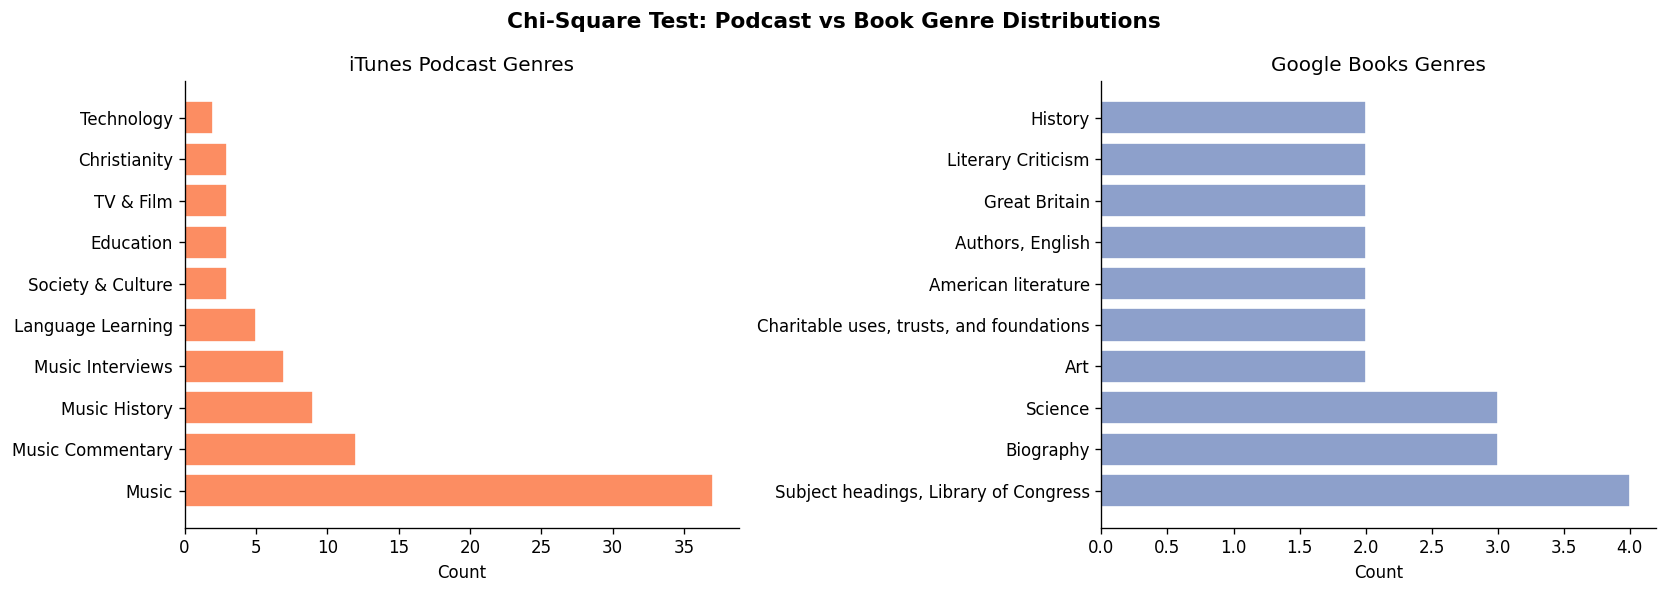

In [33]:
pod_vc = df_podcasts['genre'].drop_nulls().value_counts().sort('count', descending=True).head(10)
bk_vc  = df_books['genre'].drop_nulls().value_counts().sort('count', descending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chi-Square Test: Podcast vs Book Genre Distributions', fontsize=13, fontweight='bold')

axes[0].barh(pod_vc['genre'].to_list(), pod_vc['count'].to_list(), color=PALETTE[1], edgecolor='white')
axes[0].set_title('iTunes Podcast Genres')
axes[0].set_xlabel('Count')

axes[1].barh(bk_vc['genre'].to_list(), bk_vc['count'].to_list(), color=PALETTE[2], edgecolor='white')
axes[1].set_title('Google Books Genres')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('outputs/fig_chi_square.png', bbox_inches='tight')
plt.show()

### Findings for Test 3
The chi-square test finds only two shared genres between iTunes podcasts and Google Books — Education and History — which is a very small overlap to test on. With a chi-square statistic of just 0.109, a degree of freedom of 1, and a p-value of 0.74, we fail to reject the null hypothesis, meaning the genre distributions between podcasts and books are statistically independent. Looking at the bar charts, the two sources have very different distributions — podcasts are dominated by Music and Music Commentary due to our music-focused queries, while books are spread across History, Biography, Science, and literary categories. The conclusion for the project is that with the current query set, podcasts and books don't share enough genre vocabulary to detect a meaningful relationship. Adding more topic-based queries like "history", "science", and "biography" to the podcast search would likely increase the shared genre overlap and give this test more statistical power in future iterations.